# Figure 2: Kim-Forger SNF Parameter Space

The task taken up in this notebook is reproducing Figure 2 from the manuscript; that is, the global picture of the $K_dA$-parameter plane for the Kim&ndash;Forger SNF model. This consists of the following steps:
1. Fix the value of $K_d$.
2. Determine a lower and upper bound for $A$ corresponding to the boundary of the periodic regime.
3. For $A$ values in that interval, simulate the ODEs, estimate the period, and use numerical derivatives to estimate IPH points.  
4. Increment $K_d$ and repeat. 
5. Use nearest-neighbor tracking to assign IPH points to a branch. In other words, compare each detected IPH point to the most recent point on each existing branch, the attach the point to the branch that is closest.

**Note:** Expect for simulating the ODEs over the grid that is generated within the periodic regime to be time consuming (roughly 30-45 minutes). If desired, this step can be skipped and later code cells will load the already generated `/data/iph_curves.csv`.  

In [ ]:
# import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from kim_forger_snf.iph import find_iph_points
from kim_forger_snf.hopf import A_GENERALIZED_HOPF, hopf_curve

The next code cell simulates the ODEs over a grid contained within the periodic regime and identifies IPH points. The data obtained from this procedure is saved as `/data/iph_points_all.csv`. Note this cell has the longest runtime out of all of the notebooks. If desired, one can skip running this cell and still reproduce Figure 2 by loading the already generated `/data/iph_points_all.csv` file. 

In [ ]:
# define grid of bifurcation parameter values
KD_LOWER = 1e-6
KD_UPPER = 2.65e-4
KD_STEP = 5e-6 
K_d_values = np.arange(KD_LOWER, KD_UPPER + KD_STEP, KD_STEP)

# search for IPH points in the periodic regime
rows = []
for K_d in K_d_values:
    A_grid, period, iph_points = find_iph_points(K_d)
    for iph_point in iph_points:
        rows.append({
            "K_d": iph_point.K_d,
            "A": iph_point.A,
            "period": iph_point.period,
        })

# save data and look at first few rows 
iph_df = pd.DataFrame(rows)
iph_df.to_csv('../data/iph_points_all.csv', index = False)
iph_df.head()

,K_d,A,period
0,0.000001,0.004196,4.869324
1,0.000001,0.121793,3.629343
2,0.000006,0.010354,4.393234
3,0.000006,0.119927,3.630181
4,0.000011,0.014174,4.237060


The next code cell defines a helper function that implements nearest-neighbor tracking. In addition to the IPH points dataframe generated above (`iph_df`), it has `max_A_jump` as an argument. The purpose of `max_A_jump` is to prevent a new IPH point from being assigned to unrelated branch. Smaller values of `max_A_jump` enforce smoother behavior. When identifying branches, we take `max_A_jump = 1e-2`. 

In [ ]:
def assign_iph_branches(iph_df, max_A_jump):
    branches = {}
    next_branch = 1
    assigned_rows = []

    for K_d, group in iph_df.groupby("K_d", sort=True):
        points = group.sort_values("A").to_dict("records")
        active = {
            branch: rows[-1]
            for branch, rows in branches.items()
        }

        used_branches = set()

        for point in points:
            best_branch = None
            best_distance = np.inf

            for branch, last_point in active.items():
                if branch in used_branches:
                    continue

                distance = abs(point["A"] - last_point["A"])

                if distance < best_distance:
                    best_distance = distance
                    best_branch = branch

            if best_branch is not None and best_distance <= max_A_jump:
                branch = best_branch
            else:
                branch = next_branch
                next_branch += 1
                branches[branch] = []

            row = {
                "branch": branch,
                "K_d": point["K_d"],
                "A": point["A"],
                "period": point["period"],
            }

            branches[branch].append(row)
            assigned_rows.append(row)
            used_branches.add(branch)

    return pd.DataFrame(assigned_rows)

The next code cell uses the helper function defined above, `assign_iph_branches()`, to assign the IPH points that were detected during the simulation to a branch. All branches are saved to `/data/iph_curves.csv`.

In [ ]:
branched_df = assign_iph_branches(iph_df, max_A_jump=0.01)
branched_df.to_csv("../data/iph_curves.csv", index=False)

We next generate the data the data used to plot the Hopf curve $\mathcal{H}$. In addition, the IPH curve data generated by previous code cells is loaded into the dataframe `iph_df`. This allows one to avoid running the full simulation over the grid.

In [ ]:
iph_df = pd.read_csv("../data/iph_curves.csv")

DA_HOPF = 1e-4
A_LOWER = 1e-6
A_UPPER = 0.125 
A_sub = np.arange(A_LOWER, A_GENERALIZED_HOPF + DA_HOPF, DA_HOPF)
A_super = np.arange(A_GENERALIZED_HOPF, A_UPPER + DA_HOPF, DA_HOPF)
K_d_sub = hopf_curve(A_sub)
K_d_super = hopf_curve(A_super)

The last code cell uses the data generated above to reproduce Figure 2 from the manuscript. 

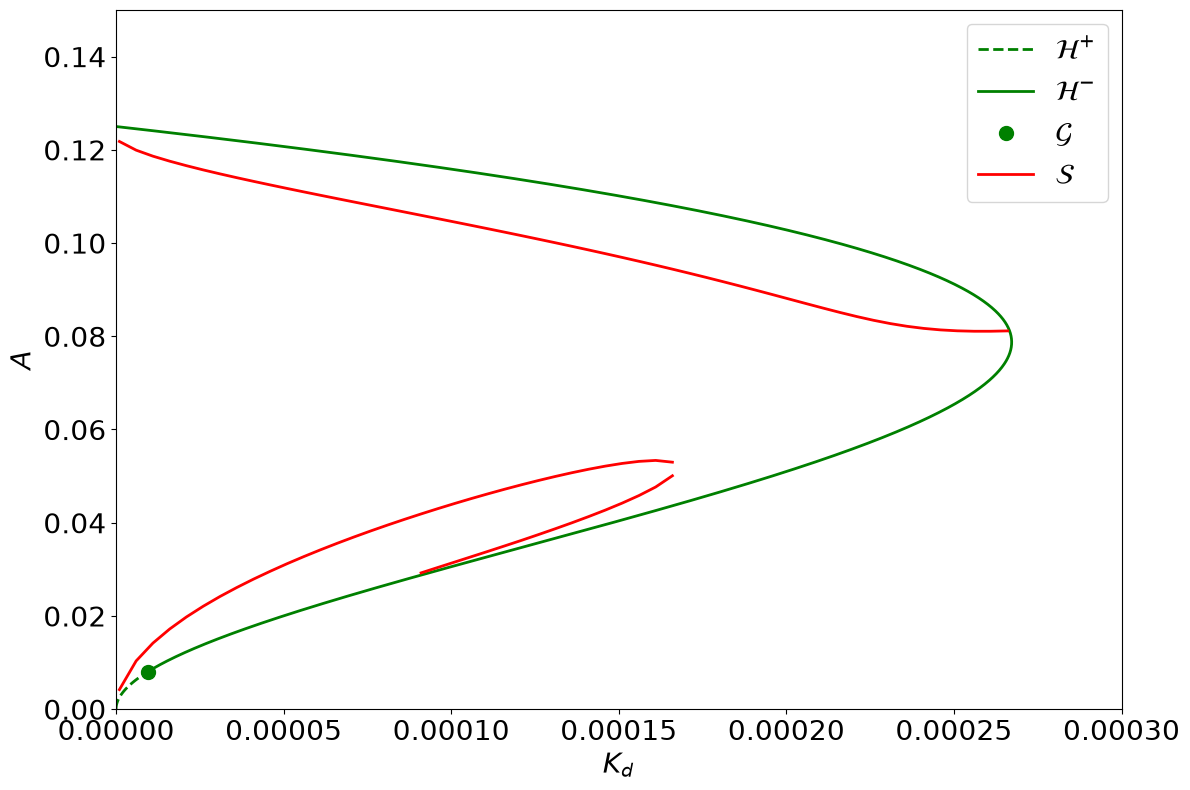

In [ ]:
fig, ax = plt.subplots(figsize = (12, 8))

# Hopf curve
ax.plot(K_d_sub, A_sub, 'g--', linewidth = 2, label = r'$\mathcal{H}^{+}$')
ax.plot(K_d_super, A_super, 'g-', linewidth = 2, label = r'$\mathcal{H}^{-}$')
ax.plot(
    hopf_curve(A_GENERALIZED_HOPF),
    A_GENERALIZED_HOPF,
    'g.',
    markersize = 20,
    label = r'$\mathcal{G}$',
)

# IPH curves
for branch, group in iph_df.groupby("branch", sort = True):
    group = group.sort_values("K_d")
    label = r"$\mathcal{S}$" if branch == iph_df["branch"].min() else None 
    ax.plot(group["K_d"], group["A"], "r-", linewidth = 2, label = label)

ax.set_xlabel(r"$K_d$", fontsize = 20)
ax.set_ylabel(r"$A$", fontsize = 20)
ax.tick_params(axis = "both", labelsize = 20)
ax.set_xlim(0, 3e-4)
ax.set_ylim(0, 0.15)
ax.legend(fontsize = 20)
fig.savefig("../outputs/figure2_parameter_space.png", dpi = 300, bbox_inches = "tight")
fig.tight_layout()